# MNIST Handwritten Digit Classification (PyTorch CNN)

## Assignment Questions (Follow in Order)

- **Q1 (15 pts):** Build the MNIST data pipeline (transforms, train/val split, DataLoaders).
- **Q2 (20 pts):** Implement a CNN classifier with the specified architecture.
- **Q3 (40 pts):** Implement training and validation functions, run training loop with checkpointing, and plot curves.
  - 3.1 (15 pts): Training function
  - 3.2 (8 pts): Validation function
  - 3.3 (11 pts): Training loop with best checkpoint saving
  - 3.4 (6 pts): Plot training and validation curves
- **Q4 (5 pts):** Load the best checkpoint and evaluate on the test set.

**Total: 80 points**

---

## Starter Notebook (Student Version)

Fill in the sections marked with:

```python
# ========== YOUR CODE STARTS HERE ==========
# ========== YOUR CODE ENDS HERE ============
```

Do **not** change the rubric section above.

In [ ]:
# If you are running in a fresh environment, uncomment to install dependencies:
# !pip -q install torch torchvision matplotlib tqdm scikit-learn

import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)


torch: 2.10.0+cpu
device: cpu


## 1. Dataset and DataLoader (15 pts)

In [ ]:
# Q1: Build the data pipeline
data_dir = "./data"
batch_size = 128  # Use 128 for training
num_workers = 0  # For fully reproducible ordering across platforms

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# 1) Create transforms for train and test (normalize with mean=0.1307, std=0.3081)
#    Avoid random augmentation for reproducibility
train_tf = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))])
test_tf = train_tf

# 2) Load MNIST datasets (train and test) using datasets.MNIST()
full_train = datasets.MNIST(root=data_dir, train=True, download=True, transform=train_tf)
test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=test_tf)

# 3) Split training set into train (55k) and validation (5k) using random_split
train_set, val_set = random_split(full_train, [55000, 5000])

# 4) Create three DataLoaders (train, val, test)
#    For train_loader, use shuffle=True
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# train_tf = None
# test_tf = None
# full_train = None
# test_set = None
# train_set, val_set = None, None
# train_loader = None
# val_loader = None
# test_loader = None
# ========== YOUR CODE ENDS HERE ============

print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val/test: 55000 5000 10000


## 2. Define the CNN Model (20 pts)

In [ ]:
# Q2: Define your CNN model
class MNISTCNN(nn.Module):
    """Input: (B,1,28,28) -> Output: (B,10)"""
    def __init__(self, num_classes=10):
        super().__init__()
        # ========== YOUR CODE STARTS HERE ==========
        # Build a CNN with:
        # - Feature extraction: 3 convolutional blocks
        #   * First block: 1 input channel to 32 output channels, with BatchNorm and ReLU, then MaxPool
        #   * Second block: 32 to 64 channels, with BatchNorm and ReLU, then MaxPool
        #   * Third block: 64 to 128 channels, with ReLU (no pooling)
        #   Use kernel_size=3 and padding=1 for all convolutions, pool_size=2 for pooling
        # - Classifier: Flatten, then fully connected layers
        #   * After two MaxPool layers, your feature map will be 7x7
        #   * First FC layer: 128*7*7 inputs to 256 outputs, with ReLU and Dropout(0.3)
        #   * Final FC layer: 256 to num_classes outputs

        # self.features = None  # Define your convolutional layers here
        # self.classifier = None  # Define your fully connected layers here

        # Feature extraction: 3 convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 28x28 -> 14x14 (due to MaxPool)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2: 14x14 -> 7x7 (due to MaxPool)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3: 7x7 -> 7x7 (no pooling)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU() )

        # Classifier: Flatten, then fully connected layers
        # After two MaxPool layers, the feature map is 128 channels of 7x7
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        # ========== YOUR CODE ENDS HERE ============

    def forward(self, x):
        # ========== YOUR CODE STARTS HERE ==========
        # Pass input through features, then classifier
        x = self.features(x)
        # Pass through classifier
        x = self.classifier(x)
        return x
        # ========== YOUR CODE ENDS HERE ============

model = MNISTCNN().to(device)
print(model)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total params: 1701322


## 3. Training Loop (40 pts)

### 3.1 Training Function (15 pts)

In [ ]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to training mode
    # - Loop through batches in the loader
    # - For each batch:
    #   * Zero gradients
    #   * Forward pass
    #   * Compute loss
    #   * Backward pass
    #   * Optimizer step
    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # Move data to the same device as the model (CPU or GPU)
        images, labels = images.to(device), labels.to(device)

        # The Standard Five
        optimizer.zero_grad()               # Clear gradients
        outputs = model(images)              # Forward pass
        loss = criterion(outputs, labels)    # Compute loss
        loss.backward()                      # Backward pass
        optimizer.step()                     # Update weights

        # Track statistics
        running_loss += loss.item() * images.size(0)

        # Get predicted labels (the index of the maximum logit)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate averages
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy

    # return None, None
    # ========== YOUR CODE ENDS HERE ============

### 3.2 Validation Function (8 pts)

In [ ]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Loop through batches
    for images, labels in loader:
        # Move data to the same device as the model
        images, labels = images.to(device), labels.to(device)

        # Forward pass ONLY
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Track total loss and count correct predictions
        running_loss += loss.item() * images.size(0)

        # Predicted labels are the index of the highest logit
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average loss and accuracy percentage
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy

    # return None, None
    # ========== YOUR CODE ENDS HERE ============

### 3.3 Training Loop (11 pts)

In [ ]:
# Q3.3: Training loop with checkpointing
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_mnist_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Loop through epochs
# - Each epoch: train, validate, log metrics
# - Track best validation accuracy and save checkpoint when improved
# - Print training and validation metrics each epoch
# - For checkpoint: save a dictionary containing keys `model_state_dict` and `epoch`

for epoch in range(1, epochs + 1):
    # 1. Run training and validation
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    # 2. Log metrics to history dictionary
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # 3. Print progress
    print(f"Epoch {epoch}/{epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # 4. Save checkpoint if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch

        checkpoint = {
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(), # Good practice for resuming
            'val_acc': val_acc
        }
        torch.save(checkpoint, ckpt_path)
        print(f"  --> New best model saved! Accuracy: {val_acc:.2f}%")

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch 1/10:
  Train Loss: 0.1357 | Train Acc: 95.76%
  Val Loss:   0.0478 | Val Acc:   98.52%
  --> New best model saved! Accuracy: 98.52%
Epoch 2/10:
  Train Loss: 0.0447 | Train Acc: 98.60%
  Val Loss:   0.0374 | Val Acc:   98.72%
  --> New best model saved! Accuracy: 98.72%
Epoch 3/10:
  Train Loss: 0.0316 | Train Acc: 99.03%
  Val Loss:   0.0372 | Val Acc:   98.92%
  --> New best model saved! Accuracy: 98.92%
Epoch 4/10:
  Train Loss: 0.0265 | Train Acc: 99.14%
  Val Loss:   0.0263 | Val Acc:   99.26%
  --> New best model saved! Accuracy: 99.26%
Epoch 5/10:
  Train Loss: 0.0220 | Train Acc: 99.31%
  Val Loss:   0.0455 | Val Acc:   98.60%
Epoch 6/10:
  Train Loss: 0.0176 | Train Acc: 99.43%
  Val Loss:   0.0274 | Val Acc:   99.18%
Epoch 7/10:
  Train Loss: 0.0169 | Train Acc: 99.44%
  Val Loss:   0.0383 | Val Acc:   98.82%
Epoch 8/10:
  Train Loss: 0.0131 | Train Acc: 99.58%
  Val Loss:   0.0423 | Val Acc:   98.84%
Epoch 9/10:
  Train Loss: 0.0129 | Train Acc: 99.59%
  Val Loss:   0

### 3.4 Plot Training Curves (6 pts)

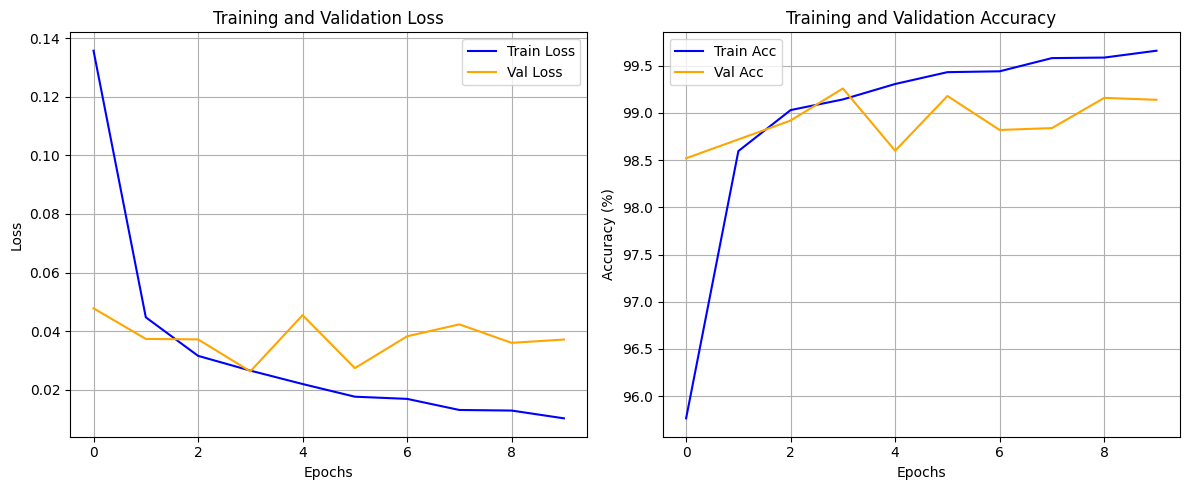

In [ ]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", color='blue')
plt.plot(history["val_loss"], label="Val Loss", color='orange')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc", color='blue')
plt.plot(history["val_acc"], label="Val Acc", color='orange')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ========== YOUR CODE ENDS HERE ============

## 4. Testing (5 pts)

In [ ]:
# Q4: Test evaluation
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Load the best checkpoint (it's a dictionary with 'model_state_dict' and 'epoch')
# - Load the model state from the checkpoint
# - Evaluate on the test set
# - Print test loss and accuracy
# test_loss, test_acc = None, None


checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
test_loss, test_acc = evaluate(model, test_loader)

# ========== YOUR CODE ENDS HERE ============

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Test loss: 0.0244 | Test acc: 99.1900
